# **Electronic Health Records (EHR) Analysis**

**Step - 01:** **Import** **The** **Libraries**

In [ ]:
# Step 1. Import Libraries

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

**Step - 02: Load The Dataset and Understand The Sturcture of Data**

In [ ]:
# Load EHR dataset (CSV format)
df = pd.read_csv("/content/EHR.csv")

In [ ]:
# Rows, Columns
print(df.shape)

(1447, 29)


In [ ]:
# Column Names
print(list(df.columns))

['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitoffset', 'hospitaladmitsource', 'hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitvisitnumber', 'unitstaytype', 'admissionweight', 'dischargeweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus', 'uniquepid']


In [ ]:
# print first 5 rows of dataset
print(df.head())

   patientunitstayid  patienthealthsystemstayid gender age  ethnicity  \
0             210014                     182373   Male  45  Caucasian   
1             200026                     174624   Male  50  Caucasian   
2             221131                     190993   Male  83  Caucasian   
3             221215                     191054   Male  49  Caucasian   
4             217835                     188445   Male  57  Caucasian   

   hospitalid  wardid                                  apacheadmissiondx  \
0          73      89  Hypertension, uncontrolled (for cerebrovascula...   
1          71      87  Ablation or mapping of cardiac conduction pathway   
2          71      87                            Endarterectomy, carotid   
3          71      87                  Infarction, acute myocardial (MI)   
4          73      92        CABG alone, coronary artery bypass grafting   

   admissionheight hospitaladmittime24  ...       unitadmitsource  \
0            178.0            13:08

**Step - 03: Data Exploration**

In [ ]:
# General info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447 entries, 0 to 1446
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientunitstayid          1447 non-null   int64  
 1   patienthealthsystemstayid  1447 non-null   int64  
 2   gender                     1444 non-null   object 
 3   age                        1446 non-null   object 
 4   ethnicity                  1405 non-null   object 
 5   hospitalid                 1447 non-null   int64  
 6   wardid                     1447 non-null   int64  
 7   apacheadmissiondx          1267 non-null   object 
 8   admissionheight            1402 non-null   float64
 9   hospitaladmittime24        1447 non-null   object 
 10  hospitaladmitoffset        1447 non-null   int64  
 11  hospitaladmitsource        1218 non-null   object 
 12  hospitaldischargeyear      1447 non-null   int64  
 13  hospitaldischargetime24    1447 non-null   objec

In [ ]:
# Summary statistics
print(df.describe(include='all'))

        patientunitstayid  patienthealthsystemstayid  gender   age  ethnicity  \
count        1.447000e+03                1447.000000    1444  1446       1405   
unique                NaN                        NaN       3    75          6   
top                   NaN                        NaN  Female  > 89  Caucasian   
freq                  NaN                        NaN     810    64       1144   
mean         6.464812e+05              494962.955079     NaN   NaN        NaN   
std          3.855454e+05              269873.698956     NaN   NaN        NaN   
min          1.424930e+05              129943.000000     NaN   NaN        NaN   
25%          2.647495e+05              227611.500000     NaN   NaN        NaN   
50%          4.212490e+05              359321.000000     NaN   NaN        NaN   
75%          1.056172e+06              782773.500000     NaN   NaN        NaN   
max          1.135186e+06              842932.000000     NaN   NaN        NaN   

         hospitalid       w

In [ ]:
# Check missing values
print(df.isnull().sum())

patientunitstayid              0
patienthealthsystemstayid      0
gender                         3
age                            1
ethnicity                     42
hospitalid                     0
wardid                         0
apacheadmissiondx            180
admissionheight               45
hospitaladmittime24            0
hospitaladmitoffset            0
hospitaladmitsource          229
hospitaldischargeyear          0
hospitaldischargetime24        0
hospitaldischargeoffset        0
hospitaldischargelocation      8
hospitaldischargestatus        7
unittype                       0
unitadmittime24                0
unitadmitsource               19
unitvisitnumber                0
unitstaytype                   0
admissionweight              134
dischargeweight              576
unitdischargetime24            0
unitdischargeoffset            0
unitdischargelocation          5
unitdischargestatus            2
uniquepid                      0
dtype: int64


In [ ]:
# Count how many patients are Male, Female, or Unknown
print(df['gender'].value_counts(dropna=False))

gender
Female     810
Male       632
NaN          3
Unknown      2
Name: count, dtype: int64


In [ ]:
# Count how many patients were admitted from each source (e.g., ER, Transfer, Clinic, etc.)
print(df['hospitaladmitsource'].value_counts(dropna=False))

hospitaladmitsource
Emergency Department    670
NaN                     229
Floor                   222
Operating Room          138
Direct Admit            116
Recovery Room            37
Other Hospital           23
Step-Down Unit (SDU)      9
ICU to SDU                2
Other ICU                 1
Name: count, dtype: int64


In [ ]:
# Count how many patients had each discharge status (e.g., Alive, Expired, Transferred, etc.)
print(df['hospitaldischargestatus'].value_counts(dropna=False))

hospitaldischargestatus
Alive      1319
Expired     121
NaN           7
Name: count, dtype: int64


**Step - 04: Data Cleaning**


In [ ]:
# Handle missing numeric values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
# Fill categorical NaNs with 'Unknown'
categorical_cols = ['gender','ethnicity','apacheadmissiondx','hospitaladmitsource',
                    'hospitaldischargelocation','hospitaldischargestatus',
                    'unitadmitsource','unitdischargelocation','unitdischargestatus']

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

In [ ]:
# Convert age (string → numeric)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [ ]:
# Create new feature: length of hospital stay (in hours → days)
df['Stay_Days'] = (df['hospitaldischargeoffset'] - df['hospitaladmitoffset']) / 24

**Step - 05: Exploratory Data Analysis (EDA)**

**a)** Patient Demographics

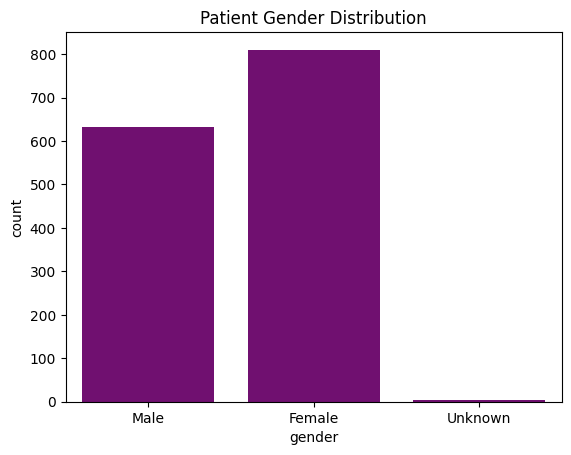

In [ ]:
# Gender distribution
sns.countplot(x="gender", data=df, color = 'purple')
plt.title("Patient Gender Distribution")
plt.show()

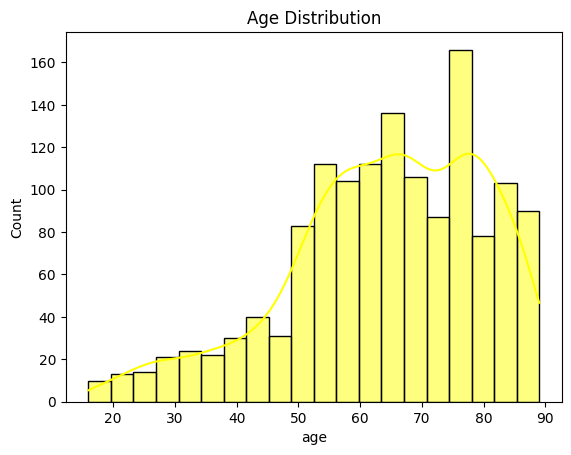

In [ ]:
# Age distribution
sns.histplot(df['age'], bins=20, kde=True, color = 'yellow')
plt.title("Age Distribution")
plt.show()

**b)** Admission Patterns

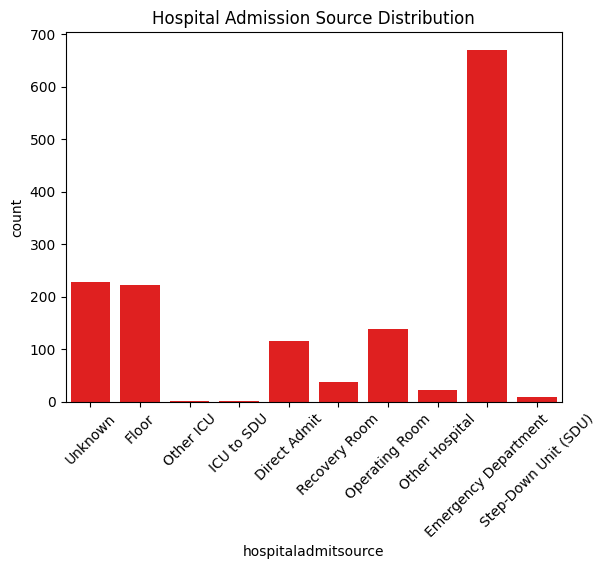

In [ ]:
# Admission source distribution
sns.countplot(x="hospitaladmitsource", data=df, color = 'red')
plt.title("Hospital Admission Source Distribution")
plt.xticks(rotation=45)
plt.show()

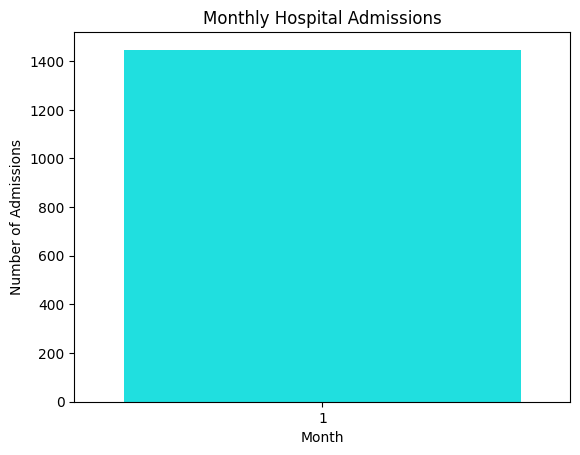

In [ ]:
# Monthly admissions
df['Admission_DateTime'] = pd.to_datetime(
    df['hospitaldischargeyear'].astype(str) + ' ' + df['hospitaladmittime24'],
    errors='coerce',
    format='%Y %H:%M:%S'  # Adjust if seconds are missing (use '%Y %H:%M')
    )

# Extract month from the combined datetime
df['Month'] = df['Admission_DateTime'].dt.month

# Plot monthly admissions
sns.countplot(x="Month", data=df, color='cyan')
plt.title("Monthly Hospital Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.show()

**c)** Hospital Stay Analysis

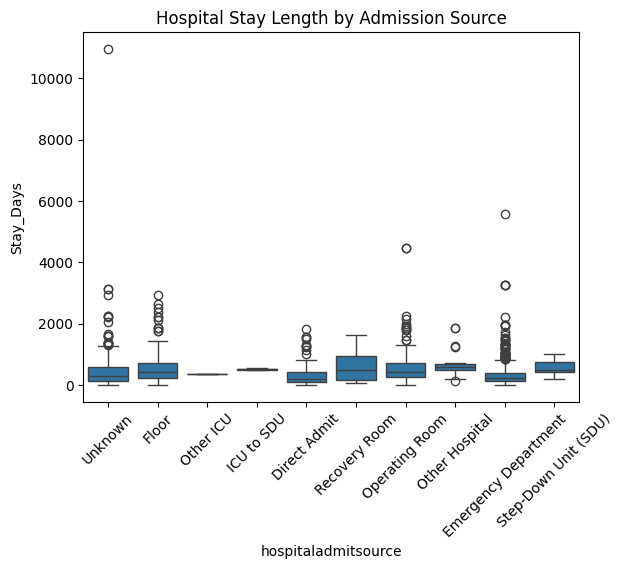

In [ ]:
# Distribution of hospital stay length
sns.boxplot(x="hospitaladmitsource", y="Stay_Days", data=df)
plt.title("Hospital Stay Length by Admission Source")
plt.xticks(rotation=45)
plt.show()

**Step - 06: Patient Outcomes Analysis**

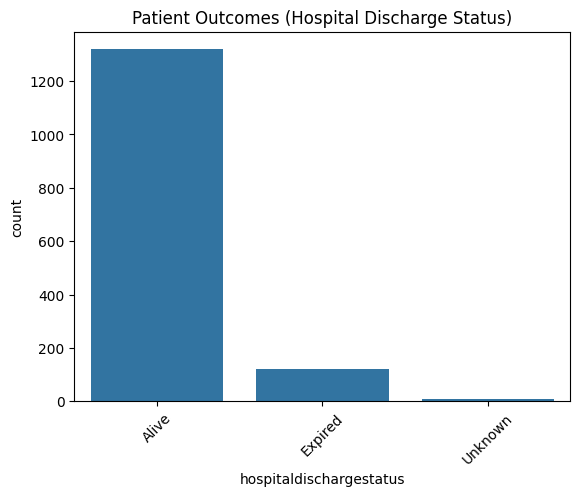

In [ ]:
# Survival rate (Discharged / Expired / Other)
sns.countplot(x="hospitaldischargestatus", data=df)
plt.title("Patient Outcomes (Hospital Discharge Status)")
plt.xticks(rotation=45)
plt.show()

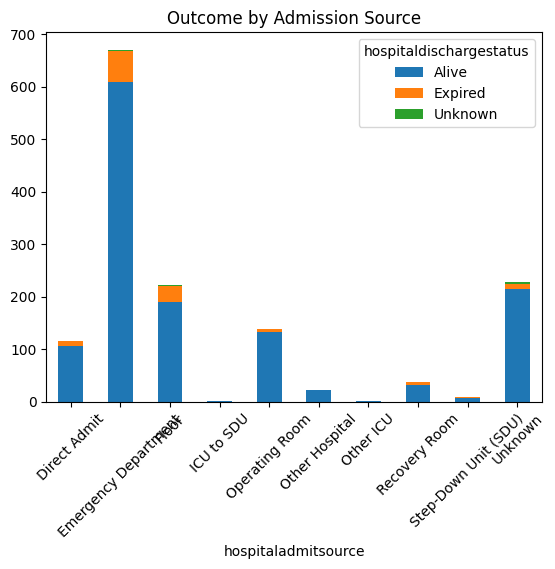

In [ ]:
# Outcome vs Admission Source
pd.crosstab(df['hospitaladmitsource'], df['hospitaldischargestatus']).plot(kind='bar', stacked=True)
plt.title("Outcome by Admission Source")
plt.xticks(rotation=45)
plt.show()